In [1]:
from tsv_to_sentences import extract_sentences_from_tsv
from gliner_latin import GLatiNER
from translator import translate_latin_to_english
from rule_based_processor import filter_entities, enforce_label_consistency
from alignment import align_latin, align_english

import pandas as pd
from simalign import SentenceAligner
from seqeval.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Task 1 directly from Latin

This was not presented as a result in EvaLatin, but I leave here the codes for reuse. Performances are very low, as can be seen below (highest F1-score for place 0.46, followed by person 0.29, tested in the provided annotated file).

In [ ]:
# multilingual

sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-sample.tsv") # annotated sample
# sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv") # test sample

ner = GLatiNER(taxonomy_file="taxonomies.json")
    
# You can now specify which set of labels to use!
df_results = ner.process(sentences_la, taxonomy_name="coarse_labels", target_sentences=None)
df_results.head()

# apply rule-based post-processing 
df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# save back to tsv
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t")
# rewrite column NER-COARSE-LIT and NER-FINE-LIT with 'O' (?)
# for now, send to new column called "LAT-COARSE", "ENG-COARSE", "LAT-FINE" and "ENG-FINE"
# tsv_output["LAT-COARSE"] = "O"

# process into BIO tags and filter out the lowercased tokens
tsv_output["LAT-COARSE"] = align_latin(
    tsv_output,
    entities_df=df_results
)

# output tsv file
tsv_output.to_csv("lat-multi-coarse.tsv", sep="\t", index=False)

In [ ]:
# large model

# sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-sample.tsv") # annotated sample
sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv") # test sample

ner = GLatiNER(model_name="fastino/gliner2-large-v1", taxonomy_file="taxonomies.json")
    
# You can now specify which set of labels to use!
df_results = ner.process(sentences_la, taxonomy_name="coarse_labels", target_sentences=None)
df_results.head()

# apply rule-based post-processing 
df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# save back to tsv
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t", header=0)
# when working with sample text: send to new column called "LAT-COARSE", "ENG-COARSE", "LAT-FINE" and "ENG-FINE"
# tsv_output["LAT-COARSE"] = "O"

# process into BIO tags and filter out the lowercased tokens
# tsv_output["LAT-COARSE"] = align_latin(
#     tsv_output,
#     entities_df=df_results
# )
tsv_output["NE-COARSE-LIT"] = align_latin(
    tsv_output,
    entities_df=df_results
)

# output tsv file
tsv_output.to_csv("send/ner-coarse_evalatin2026-ner-v0.1-test-masked_argo-navis_2.tsv", sep="\t", index=False)

In [15]:
mask = tsv_output["NE-COARSE-LIT"].notna()

y_true = [tsv_output.loc[mask, "NE-COARSE-LIT"].tolist()]
y_pred = [tsv_output.loc[mask, "LAT-COARSE"].tolist()]

print(classification_report(y_true, y_pred, zero_division=0))

              precision    recall  f1-score   support

  collective       0.33      0.08      0.13        24
    creature       0.00      0.00      0.00         0
       event       0.00      0.00      0.00         1
    language       0.00      0.00      0.00         0
        misc       0.00      0.00      0.00         4
      object       0.00      0.00      0.00         0
      person       0.60      0.19      0.29        32
       place       0.89      0.31      0.46        26
        time       0.00      0.00      0.00         0

   micro avg       0.40      0.18      0.25        87
   macro avg       0.20      0.06      0.10        87
weighted avg       0.58      0.18      0.28        87



## Task 1 Latin to English

In [2]:
# multilingual model

sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv")
# remove sentences_la containing "TOKEN"
# sentences_la = [s for s in sentences_la if "TOKEN" not in s]

# sentences_en = translate_latin_to_english(sentences_la)
# write and save translated_sentences_test.txt, now saved in sentences_en
# with open('translated_sentences_test.txt', 'w', encoding='utf-8') as f:
#     for sentence in sentences_en:
#         f.write((sentence or '') + '\n') # robust fix: if sentence is None, write empty string instead
# Instead of running translator again, we load pre-translated sentences in translated_sentences.txt
file_path = './translated_sentences_test.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    sentences_en = [line.rstrip('\n') for line in f]
    print(sentences_en[:5])

ner = GLatiNER(taxonomy_file="taxonomies.json")
    
# You can now specify which set of labels to use!
df_results = ner.process(sentences_la, target_sentences=sentences_en, taxonomy_name="coarse_labels")
# df_results.head()

# apply rule-based post-processing 
df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# tsv_output = pd.read_csv("evalatin2026-ner-v0.1-sample.tsv", sep="\t")
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t")

['But the orgies of Alcithoe Minyeias are not to be considered a god, but still the reckless Bacchumprogeniem denies that he is the offspring of Jupiter, and has associates of the sisters of impiety.', 'To celebrate the festival, the priest and the servants of the works and the ladies had to cover their breasts with skins, to loosen the ribbons from their hair, to tie their hair, to take the thyrsosius in their hands, and it was predicted by the gods that the savage would be injured.', 'They store the parents and the mothers and the nurses and the baskets and the infected burdens, and they give the turas, and they call Bacchus, Bromium, and Lyaeus, and the fire-generating, and again the sole bimother: to these are added Nyseus, and the unshorn Thyoneus, and with Lenaeus, the genial planter of grapes, and Nyctelius, and Eleleus, the parent, and Iacchus, and Euhan, and which, moreover, through the Graias, thou hast the names of many nations, Liber.', 'For you have unconsummated youth, yo

In [ ]:
tsv_output = align_english(df_results, tsv_output, column_name='NE-COARSE-LIT')

tsv_output.to_csv("send/ner-coarse_evalatin2026-ner-v0.1-test-masked_argo-navis_1.tsv", sep="\t", index=False)

In [ ]:
tsv_output = pd.read_csv("tsv_output.tsv", sep="\t")

mask = tsv_output["NE-COARSE-LIT"].notna()

y_true = [tsv_output.loc[mask, "NE-COARSE-LIT"].tolist()]
y_pred = [tsv_output.loc[mask, "ENG-COARSE"].tolist()]

print(classification_report(y_true, y_pred, zero_division=0))
# len(y_true), len(y_pred)

              precision    recall  f1-score   support

  collective       0.68      0.62      0.65        24
    creature       0.00      0.00      0.00         0
       event       0.33      1.00      0.50         1
    language       0.00      0.00      0.00         0
        misc       0.00      0.00      0.00         4
      object       0.00      0.00      0.00         0
      person       0.88      0.47      0.61        32
       place       0.70      0.81      0.75        26
        time       0.00      0.00      0.00         0

   micro avg       0.60      0.60      0.60        87
   macro avg       0.29      0.32      0.28        87
weighted avg       0.73      0.60      0.63        87



In [5]:
# rerun with large model

sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv")
# remove sentences_la containing "TOKEN"
# sentences_la = [s for s in sentences_la if "TOKEN" not in s]

# sentences_en = translate_latin_to_english(sentences_la)
# Instead of running translator again, we load pre-translated sentences in translated_sentences.txt
file_path = './translated_sentences_test.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    sentences_en = [line.rstrip('\n') for line in f]
    # print(sentences_en[:5])

ner = GLatiNER(model_name="fastino/gliner2-large-v1", taxonomy_file="taxonomies.json")
    
# You can now specify which set of labels to use!
df_results = ner.process(sentences_la, target_sentences=sentences_en, taxonomy_name="coarse_labels")
# df_results.head()

# apply rule-based post-processing 
df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# tsv_output = pd.read_csv("evalatin2026-ner-v0.1-sample.tsv", sep="\t")
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t")
tsv_output = align_english(df_results, tsv_output, column_name='NE-COARSE-LIT')

tsv_output.to_csv("send/ner-coarse_evalatin2026-ner-v0.1-test-masked_argo-navis_2.tsv", sep="\t", index=False)

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


Some weights of XLMRobertaModel were not initialized from the model checkpoint at UGARIT/grc-alignment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-02-19 12:21:26,116 - simalign.simalign - INFO - Initialized the EmbeddingLoader with model: UGARIT/grc-alignment


#### Evaluation

In [17]:
mask = tsv_output["NE-COARSE-LIT"].notna()

y_true = [tsv_output.loc[mask, "NE-COARSE-LIT"].tolist()]
y_pred = [tsv_output.loc[mask, "ENG-COARSE"].tolist()]

print(classification_report(y_true, y_pred, zero_division=0))

              precision    recall  f1-score   support

  collective       0.75      0.62      0.68        24
    creature       0.00      0.00      0.00         0
       event       0.50      1.00      0.67         1
        misc       0.00      0.00      0.00         4
      object       0.00      0.00      0.00         0
      person       0.76      0.59      0.67        32
       place       0.66      0.81      0.72        26
        work       0.00      0.00      0.00         0

   micro avg       0.68      0.64      0.66        87
   macro avg       0.33      0.38      0.34        87
weighted avg       0.69      0.64      0.66        87



In [ ]:
from sklearn.metrics import confusion_matrix
y_true = tsv_output.loc[mask, "NE-COARSE-LIT"].tolist()
y_pred = tsv_output.loc[mask, "ENG-COARSE"].tolist()
labels = sorted(set(y_true) | set(y_pred))  # ensures consistent order

cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
# print(cm_df)

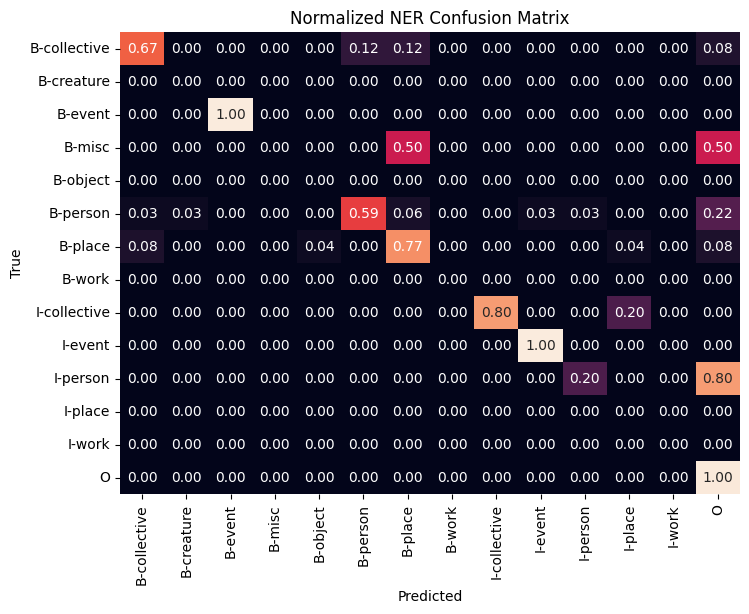

In [24]:
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized NER Confusion Matrix")
plt.show()

In [16]:
eng_multi_fine = pd.read_csv("/Users/ripoll_alberola/Documents/PhD/presentations & lessons & papers & conferences/LREC 2026 Palma de Mallorca/EvaLatin/csvs-to-Fernando/eng-multi-fine.tsv", sep="\t")
eng_multi_fine.head()
# ENG-COARSE column should be saved where NE-FINE-LIT is, and then deleted
eng_multi_fine['NE-FINE-LIT'] = eng_multi_fine['ENG-FINE']
eng_multi_fine = eng_multi_fine.drop(columns=['ENG-FINE'])
eng_multi_fine.to_csv("/Users/ripoll_alberola/Documents/PhD/presentations & lessons & papers & conferences/LREC 2026 Palma de Mallorca/EvaLatin/csvs-to-Fernando/eng-multi-fine.tsv", sep="\t", index=False)

## Task 2 in English

In [7]:
# multilingual model

sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv")
# remove sentences_la containing "TOKEN"
# sentences_la = [s for s in sentences_la if "TOKEN" not in s]

# sentences_en = translate_latin_to_english(sentences_la)
# Instead of running translator again, we load pre-translated sentences in translated_sentences.txt
file_path = './translated_sentences_test.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    sentences_en = [line.rstrip('\n') for line in f]
    # print(sentences_en[:5])

ner = GLatiNER(taxonomy_file="taxonomies.json")
df_results = ner.process(sentences_la, target_sentences=sentences_en, taxonomy_name="fine_labels")

df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# tsv_output = pd.read_csv("evalatin2026-ner-v0.1-sample.tsv", sep="\t")
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t", header=0)
tsv_output = align_english(df_results, tsv_output, column_name='NE-FINE-LIT')

tsv_output.to_csv("send/ner-fine_evalatin2026-ner-v0.1-test-masked_argo-navis_1.tsv", sep="\t", index=False)

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


Some weights of XLMRobertaModel were not initialized from the model checkpoint at UGARIT/grc-alignment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-02-19 12:53:03,331 - simalign.simalign - INFO - Initialized the EmbeddingLoader with model: UGARIT/grc-alignment


In [8]:
# large model 

sentences_la = extract_sentences_from_tsv("evalatin2026-ner-v0.1-test-masked.tsv")
# remove sentences_la containing "TOKEN"
# sentences_la = [s for s in sentences_la if "TOKEN" not in s]

# sentences_en = translate_latin_to_english(sentences_la)
# Instead of running translator again, we load pre-translated sentences in translated_sentences.txt
file_path = './translated_sentences_test.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    sentences_en = [line.rstrip('\n') for line in f]
    # print(sentences_en[:5])

ner = GLatiNER(model_name="fastino/gliner2-large-v1", taxonomy_file="taxonomies.json")
df_results = ner.process(sentences_la, target_sentences=sentences_en, taxonomy_name="fine_labels")

df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# tsv_output = pd.read_csv("evalatin2026-ner-v0.1-sample.tsv", sep="\t")
tsv_output = pd.read_csv("evalatin2026-ner-v0.1-test-masked.tsv", sep="\t", header=0)
tsv_output = align_english(df_results, tsv_output, column_name='NE-FINE-LIT')

tsv_output.to_csv("send/ner-fine_evalatin2026-ner-v0.1-test-masked_argo-navis_2.tsv", sep="\t", index=False)

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


Some weights of XLMRobertaModel were not initialized from the model checkpoint at UGARIT/grc-alignment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-02-19 13:25:47,648 - simalign.simalign - INFO - Initialized the EmbeddingLoader with model: UGARIT/grc-alignment


In [34]:
mask = tsv_output["NE-FINE-LIT"].notna()

y_true = [tsv_output.loc[mask, "NE-FINE-LIT"].tolist()]
y_pred = [tsv_output.loc[mask, "ENG-FINE"].tolist()]

print(classification_report(y_true, y_pred, zero_division=0))

                         precision    recall  f1-score   support

             collective       0.00      0.00      0.00         3
      collective.ethnic       0.33      0.05      0.09        20
collective.organization       0.00      0.00      0.00         1
                  event       0.00      0.00      0.00         1
                   misc       0.00      0.00      0.00         4
                 person       0.75      0.44      0.56        27
        person.ancestry       0.00      0.00      0.00         2
      person.derivative       0.00      0.00      0.00         1
         person.epithet       0.00      0.00      0.00         1
          person.ethnic       0.00      0.00      0.00         0
    person.mythological       0.00      0.00      0.00         1
                  place       0.71      0.68      0.69        25
       place.derivative       0.00      0.00      0.00         1
                   work       0.00      0.00      0.00         0

              micro avg

In [25]:
ner = GLatiNER(taxonomy_file="taxonomies.json")
df_results = ner.process(sentences_la, target_sentences=sentences_en, taxonomy_name="fine_labels")

df_results["entities"] = df_results["entities"].apply(filter_entities, threshold=0.65)
df_results["entities"] = enforce_label_consistency(df_results["entities"])

# tsv_output = pd.read_csv("evalatin2026-ner-v0.1-sample.tsv", sep="\t")
tsv_output = pd.read_csv("tsv_output.tsv", sep="\t")
tsv_output = align_english(df_results, tsv_output, column_name='ENG-FINE')

tsv_output.to_csv("eng-multi-fine.tsv", sep="\t", index=False)

🧠 Model Configuration
Encoder model      : microsoft/mdeberta-v3-base
Counting layer     : count_lstm
Token pooling      : first


Some weights of XLMRobertaModel were not initialized from the model checkpoint at UGARIT/grc-alignment and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-02-18 17:50:41,535 - simalign.simalign - INFO - Initialized the EmbeddingLoader with model: UGARIT/grc-alignment


In [30]:
mask = tsv_output["NE-FINE-LIT"].notna()

y_true = [tsv_output.loc[mask, "NE-FINE-LIT"].tolist()]
y_pred = [tsv_output.loc[mask, "ENG-FINE"].tolist()]

print(classification_report(y_true, y_pred, zero_division=0))

                         precision    recall  f1-score   support

             collective       0.00      0.00      0.00         3
      collective.ethnic       1.00      0.10      0.18        20
collective.organization       0.00      0.00      0.00         1
               creature       0.00      0.00      0.00         0
                  event       0.00      0.00      0.00         1
                   misc       0.00      0.00      0.00         4
                 person       0.73      0.30      0.42        27
        person.ancestry       0.00      0.00      0.00         2
      person.derivative       0.00      0.00      0.00         1
         person.epithet       0.00      0.00      0.00         1
    person.mythological       0.00      0.00      0.00         1
                  place       0.73      0.76      0.75        25
       place.derivative       0.00      0.00      0.00         1

              micro avg       0.60      0.33      0.43        87
              macro avg